#HOTEL BOOKING CANCELLATION PREDICTION

## Week 2 — From Clean Data to Machine Learning




**Dataset:** Hotel Booking Demand Dataset  
**Task:** Predict whether a hotel booking will be cancelled



### Machine Learning Workflow

Problem Definition → Data Preparation → Baseline Model → Model Training → Model Evaluation → Model Comparison → Overfitting Check → Feature Importance → Business Recommendations

## 1. PROBLEM DEFINITION





### 1.1 Business Problem



Hotel booking cancellations can create significant challenges for hotel management. When a customer cancels a reservation, the hotel may lose expected revenue and may also have difficulty efficiently managing room availability.

The objective of this task is to use historical hotel booking information to identify patterns associated with booking cancellations and build a machine learning model that can predict whether a new booking is likely to be cancelled.

### 1.2 Objective



The main objective of Week 2 is to develop and evaluate machine learning classification models that can predict hotel booking cancellations.

The specific objectives are:

1. Define the cancellation prediction problem.
2. Prepare the cleaned Week 1 dataset for machine learning.
3. Identify useful and unsuitable features.
4. Prevent data leakage.
5. Separate the dataset into input features (X) and target variable (y).
6. Check the distribution of the target variable.
7. Encode categorical variables and scale numerical variables where required.
8. Build Logistic Regression as a baseline model.
9. Train Decision Tree and Random Forest models.
10. Evaluate all models using multiple performance metrics.
11. Compare the models and select the best model based on evidence.
12. Check for overfitting.
13. Identify the most important features.
14. Translate model findings into practical business recommendations.

### 1.3 Target Variable



The target variable selected for this machine learning task is:

**`is_canceled`**

The variable represents the cancellation status of a hotel booking:

- `0` = Booking was not cancelled
- `1` = Booking was cancelled

This makes the problem a **binary classification problem**, because the model must predict one of two possible outcomes.

### 1.4 Why Was `is_canceled` Chosen as the Target?



The `is_canceled` variable was selected because it directly represents the business outcome that the hotel wants to predict.

The Week 1 analysis already identified meaningful relationships between cancellation behavior and several booking characteristics, including lead time, hotel type, deposit type, customer type, previous cancellation history, and special requests.

Therefore, the Week 2 task converts the descriptive findings from Week 1 into a predictive machine learning problem.

The target is binary, making binary classification models such as Logistic Regression, Decision Tree, and Random Forest suitable for this task.

### 1.5 Success Criteria



Model performance will not be judged using accuracy alone.

The following evaluation metrics will be used:

- **Accuracy** — overall percentage of correct predictions.
- **Precision** — proportion of predicted cancellations that were actually cancellations.
- **Recall** — proportion of actual cancellations correctly identified.
- **F1 Score** — balance between precision and recall.
- **ROC AUC** — ability of the model to distinguish between cancelled and non-cancelled bookings.
- **Confusion Matrix** — detailed view of correct and incorrect predictions.

The final model will be selected based on overall evidence from these metrics rather than simply choosing the model with the highest accuracy.

IMPORT LIBRARIES

In [60]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

print("All required libraries have been imported successfully.")

All required libraries have been imported successfully.


#### Findings

All required Python libraries were imported successfully.

The libraries will be used for:

- Data handling and inspection using Pandas and NumPy.
- Visualization using Matplotlib and Seaborn.
- Data splitting using `train_test_split`.
- Categorical encoding and numerical scaling using Scikit-learn preprocessing tools.
- Machine learning using Logistic Regression, Decision Tree, and Random Forest.
- Model evaluation using classification metrics.
- Saving the final trained model using Joblib.

The next step is to load the cleaned dataset prepared during Week 1.

##2. DATA PREPARATION



### 2.1 Load the Cleaned Dataset



The cleaned and feature-engineered dataset produced during Week 1 will be used as the starting point for Week 2.

The dataset has already undergone data-quality investigation, duplicate treatment, missing-value handling, category standardization, data-type correction, and feature engineering.

LOAD DATASET

In [61]:
# Load the cleaned Week 1 dataset

df = pd.read_csv("hotel_bookings_cleaned.csv")

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (87389, 36)


BASIC INSPECTION

In [62]:
# Display the first five rows

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_stay_nights,room_type_changed,total_guests,is_family,is_long_stay
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,Unknown,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,False,2.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,Unknown,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,False,2.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,Unknown,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,True,1.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,False,1.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,False,2.0,0,0


In [63]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87389 entries, 0 to 87388
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87389 non-null  object 
 1   is_canceled                     87389 non-null  int64  
 2   lead_time                       87389 non-null  int64  
 3   arrival_date_year               87389 non-null  int64  
 4   arrival_date_month              87389 non-null  object 
 5   arrival_date_week_number        87389 non-null  int64  
 6   arrival_date_day_of_month       87389 non-null  int64  
 7   stays_in_weekend_nights         87389 non-null  int64  
 8   stays_in_week_nights            87389 non-null  int64  
 9   adults                          87389 non-null  int64  
 10  children                        87389 non-null  float64
 11  babies                          87389 non-null  int64  
 12  meal                            

In [64]:
# Display number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 87389
Number of columns: 36


#### Findings

The cleaned dataset contains **87,389 observations and 36 columns**.

The dataset represents hotel booking records containing information about booking characteristics, guest information, stay details, customer history, market information, and other booking-related variables.

This dataset was previously cleaned and feature-engineered during Week 1. Therefore, the Week 2 workflow starts from the validated Week 1 dataset rather than repeating the complete data-cleaning process.

### 2.2 Data Quality Recheck



Although the dataset was cleaned during Week 1, the final dataset must be checked again before machine learning.

This verification is important because the machine learning workflow should use the exact dataset that was inspected and approved.

The following checks will be performed:

1. Missing values
2. Duplicate rows
3. Data types
4. Dataset dimensions

MISSING VALUES

In [65]:
# Check missing values

missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

display(
    missing_values[missing_values > 0]
    .to_frame("Missing Values")
)

Total missing values: 0


,Missing Values


DUPLICATE ROWS

In [66]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 0


DATA TYPES

In [67]:
# Check data types

display(df.dtypes.to_frame("Data Type"))

,Data Type
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


#### Findings

The Week 1 cleaning process resulted in a final dataset with:

- **0 missing values**
- **0 duplicate rows**
- Corrected data types, including `reservation_status_date` converted to datetime
- **87,389 rows**
- **36 columns**

The dataset therefore passes the basic data-quality checks required before model preparation.

Because the data was already cleaned during Week 1, no additional general cleaning operation is performed here unless the verification identifies an unexpected issue.

### 2.3 Target Variable Distribution



Before training the models, the distribution of the target variable `is_canceled` must be examined.

This is important because an imbalanced target can make accuracy misleading. For example, if one class represents a much larger proportion of bookings, a model could achieve high accuracy while performing poorly on the smaller class.

Therefore, both the count and percentage of cancelled and non-cancelled bookings will be examined.

In [68]:
# Target variable distribution

target_counts = df["is_canceled"].value_counts()

target_percentages = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages
})

display(target_distribution)

,Count,Percentage
is_canceled,,
0,63364,72.51
1,24025,27.49


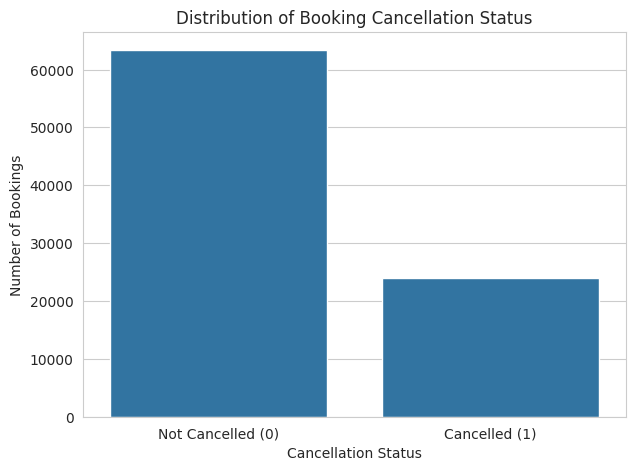

In [69]:
# Visualize target distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_canceled"
)

plt.title("Distribution of Booking Cancellation Status")
plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")

plt.xticks(
    [0, 1],
    ["Not Cancelled (0)", "Cancelled (1)"]
)

plt.show()

#### Findings

The target variable `is_canceled` contains two classes:

- **0 — Not Cancelled:** 63,364 bookings (**72.51%**)
- **1 — Cancelled:** 24,025 bookings (**27.49%**)

Therefore, approximately **27.49% of the bookings were cancelled**, while **72.51% were not cancelled**.

The target variable is moderately imbalanced because the non-cancelled class is substantially larger than the cancelled class.

This imbalance is important when evaluating the machine learning models. Accuracy alone may not provide a complete picture of model performance. Therefore, Precision, Recall, F1 Score, ROC AUC, and the Confusion Matrix will also be considered.

### 2.4 Feature Selection and Data Leakage Prevention



Not every column in the dataset should automatically be given to a machine learning model.

A feature should be used only when its information would realistically be available at the time the prediction is made.

Some columns in the Hotel Booking Demand dataset describe information that can become available after the original booking decision or are strongly connected to the final reservation outcome.

Including such variables can cause **data leakage**.

Data leakage occurs when information that would not realistically be available at prediction time is used by the model. This can produce artificially high model performance and make the model unreliable in real business use.

### 2.5 Columns Removed Before Modeling



The following columns will be excluded from the machine learning feature set:

1. `reservation_status`
2. `reservation_status_date`
3. `assigned_room_type`
4. `room_type_changed`
5. `booking_changes`
6. `agent`

The decision is based on prediction-time availability, analytical relevance, and leakage prevention.

In [70]:
# Columns excluded from the modeling dataset

columns_to_remove = [
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
    "room_type_changed",
    "booking_changes",
    "agent"
]

# Create modeling dataset
modeling_df = df.drop(columns=columns_to_remove)

print("Columns removed:")
for column in columns_to_remove:
    print("-", column)

print("\nOriginal shape:", df.shape)
print("Modeling dataset shape:", modeling_df.shape)

Columns removed:
- reservation_status
- reservation_status_date
- assigned_room_type
- room_type_changed
- booking_changes
- agent

Original shape: (87389, 36)
Modeling dataset shape: (87389, 30)


#### Why These Columns Were Removed

##### `reservation_status`

This variable describes the final reservation status and is therefore very closely related to the target outcome. Using it can reveal the answer to the model rather than allowing the model to predict the answer.

##### `reservation_status_date`

This date is associated with the reservation status and can contain information about the final outcome. It is therefore not appropriate for an early cancellation prediction model.

##### `assigned_room_type`

The assigned room can represent information that becomes available after or during the booking process rather than at the original prediction point.

##### `room_type_changed`

A room-type change may occur after the original reservation and therefore may represent later information.

##### `booking_changes`

Booking changes can occur after the original booking and may contain information that would not be available when the initial cancellation-risk prediction is made.

##### `agent`

`agent` behaves more like an identifier than a general behavioral characteristic. Using such an identifier can allow the model to learn patterns associated with particular agents rather than generalizable booking behavior.

#### Leakage Prevention Decision

These variables are therefore excluded to create a more realistic prediction setting and reduce the risk of data leakage.

#### Findings

Six columns were removed from the original 36-column dataset:

1. `reservation_status`
2. `reservation_status_date`
3. `assigned_room_type`
4. `room_type_changed`
5. `booking_changes`
6. `agent`

After removing these variables, the dataset contains **30 columns**, including the target variable.

The number of observations remains unchanged at **87,389 rows**.

The removed variables were excluded because they may contain outcome-related, post-booking, or identifier-like information that could introduce data leakage or reduce the model's ability to generalize to new bookings.

The purpose of this step is to ensure that the machine learning models learn from appropriate booking characteristics rather than information that may reveal the final reservation outcome.

### 2.6 Separate Features (X) and Target (y)



The machine learning dataset is divided into two parts:

- **X** = input features used by the model
- **y** = target variable that the model attempts to predict

The target variable is `is_canceled`.

In [71]:
# Separate input features and target

X = modeling_df.drop(columns=["is_canceled"])
y = modeling_df["is_canceled"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget variable:")
print(y.name)

print("\nNumber of input features:")
print(X.shape[1])

X shape: (87389, 29)
y shape: (87389,)

Target variable:
is_canceled

Number of input features:
29


#### Findings

The modeling dataset was separated into input features and the target variable.

- **X:** 87,389 observations × 29 input features
- **y:** 87,389 target observations
- **Target:** `is_canceled`

The 29 input features will be used by the machine learning algorithms to predict whether a booking will be cancelled.

The target variable contains the two classes:

- `0` = Not Cancelled
- `1` = Cancelled

The separation of X and y prepares the dataset for the train-test split and subsequent model training.

### 2.7 Identify Numerical and Categorical Features



The dataset contains both numerical and categorical variables.

Numerical variables contain measurable values such as lead time, number of nights, number of guests, ADR, and special requests.

Categorical variables represent groups or categories such as hotel type, meal type, market segment, deposit type, and customer type.

These two feature types require different preprocessing techniques.

In [72]:
# Identify categorical and numerical features

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Number of categorical features:", len(categorical_features))
print("Number of numerical features:", len(numerical_features))

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Number of categorical features: 9
Number of numerical features: 20

Categorical features:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']

Numerical features:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_stay_nights', 'total_guests', 'is_family', 'is_long_stay']


#### Findings

The predictor variables consist of both numerical and categorical features.

Categorical variables cannot be directly used by most machine learning algorithms in their original text form, so they will be converted into numerical representations using **One-Hot Encoding**.

Numerical features will be standardized where required. This is particularly important for Logistic Regression because features with very different scales can affect the model's optimization.

The preprocessing will be implemented through a Scikit-learn pipeline so that transformations are learned from the training data only.

### 2.8 Training and Testing Data



The dataset will be divided into:

- **80% training data**
- **20% testing data**

The training dataset will be used to learn model parameters.

The testing dataset will remain unseen during training and will be used to evaluate how well the trained models generalize to new observations.

A fixed random state will be used to make the experiment reproducible.

Stratification will also be applied using the target variable so that the cancellation proportion remains approximately consistent between the training and testing sets.

In [73]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (69911, 29)
y_train: (69911,)

Testing set:
X_test: (17478, 29)
y_test: (17478,)


CHECKING CLASS BALANCE AFTER SPLIT

In [74]:
# Compare target distribution in training and testing data

train_distribution = (
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

split_distribution = pd.DataFrame({
    "Training %": train_distribution,
    "Testing %": test_distribution
})

display(split_distribution)

,Training %,Testing %
is_canceled,,
0,72.51,72.51
1,27.49,27.49


#### Findings

The dataset was divided into training and testing subsets using an 80/20 split.

Stratified sampling was used so that both datasets maintain a similar proportion of cancelled and non-cancelled bookings.

This is important because the testing set should represent the same target distribution as the data used during model development.

The test set will remain unseen during model fitting and will therefore provide the main evidence for model performance.

### 2.9 Feature Preprocessing



Machine learning algorithms require the input data to be represented appropriately.

#### Categorical Features

Categorical variables will be converted into numerical variables using **One-Hot Encoding**.

For example, a variable such as hotel type can be transformed into separate binary indicators.

#### Numerical Features

Numerical features will be standardized using `StandardScaler`.

Standardization transforms numerical variables to a common scale and is particularly useful for Logistic Regression.

#### Missing Values

Although the Week 1 final dataset contains zero missing values, imputation steps will be included in the preprocessing pipeline as an additional safeguard.

The preprocessing will be performed inside a Scikit-learn pipeline to prevent information from the testing data from influencing the training process.

PREPROCESSOR

In [75]:
# Create preprocessing pipeline

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print("Numerical features: imputation + scaling")
print("Categorical features: imputation + one-hot encoding")

Preprocessing pipeline created successfully.
Numerical features: imputation + scaling
Categorical features: imputation + one-hot encoding


#### Findings

The preprocessing pipeline has been created successfully.

Numerical variables will be imputed using the median and standardized using `StandardScaler`.

Categorical variables will be imputed using the most frequent category and converted into binary indicator variables using One-Hot Encoding.

Using a single preprocessing pipeline ensures that the same transformations are consistently applied during training and testing while reducing the risk of data leakage.

## 3. BASELINE MODEL

### 3.1 Purpose of a Baseline Model



Before training multiple machine learning models, a baseline model is established as a reference point.

A baseline provides an initial level of performance against which more complex models can be compared.

For this task, **Logistic Regression** is selected as the baseline classifier because:

- It is designed for classification problems.
- It is suitable for binary outcomes such as `is_canceled`.
- It is relatively simple and computationally efficient.
- Its results provide an interpretable benchmark.
- Its performance can be compared with more complex models such as Decision Tree and Random Forest.

The purpose of the baseline is not necessarily to obtain the highest performance. Instead, it provides a reference that helps determine whether more complex models provide meaningful improvement.

### 3.2 Logistic Regression Baseline



Logistic Regression is a supervised classification algorithm that estimates the probability of an observation belonging to a particular class.

In this project, the model estimates the probability that a hotel booking will be cancelled.

The model produces a probability between 0 and 1. A classification threshold is then used to convert the probability into a predicted class:

- Probability below the threshold → `0` (Not Cancelled)
- Probability at or above the threshold → `1` (Cancelled)

The default classification threshold of **0.50** will be used for the baseline model.

BUILD BASELINE

In [76]:
# Create the Logistic Regression baseline pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Logistic Regression baseline pipeline created successfully.")

Logistic Regression baseline pipeline created successfully.


TRAIN

In [77]:
# Train the Logistic Regression baseline

logistic_model.fit(X_train, y_train)

print("Logistic Regression baseline trained successfully.")

Logistic Regression baseline trained successfully.


PREDICTIONS

In [78]:
# Generate predictions on the unseen test set

y_pred_logistic = logistic_model.predict(X_test)

# Generate probability predictions for ROC AUC
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_logistic))

Predictions generated successfully.
Number of predictions: 17478


BASELINE METRICS

In [79]:
# Calculate baseline evaluation metrics

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic
)

logistic_roc_auc = roc_auc_score(
    y_test,
    y_prob_logistic
)

logistic_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_roc_auc
    ]
})

logistic_results["Score"] = logistic_results["Score"].round(4)

display(logistic_results)

,Metric,Score
0,Accuracy,0.7901
1,Precision,0.6745
2,Recall,0.4572
3,F1 Score,0.5450
4,ROC AUC,0.8325


CLASSIFICATION REPORT

In [80]:
# Detailed classification report

print("Logistic Regression Classification Report")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=[
            "Not Cancelled",
            "Cancelled"
        ]
    )
)

Logistic Regression Classification Report
               precision    recall  f1-score   support

Not Cancelled       0.82      0.92      0.86     12673
    Cancelled       0.67      0.46      0.55      4805

     accuracy                           0.79     17478
    macro avg       0.75      0.69      0.70     17478
 weighted avg       0.78      0.79      0.78     17478



CONFUSION MATRIX

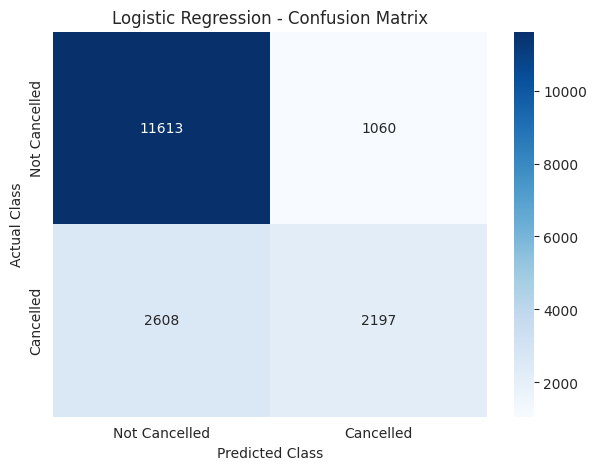

In [81]:
# Confusion Matrix for Logistic Regression

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Cancelled",
        "Cancelled"
    ],
    yticklabels=[
        "Not Cancelled",
        "Cancelled"
    ]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

### 3.3 Logistic Regression Baseline Results



The Logistic Regression model was evaluated on the unseen test dataset using Accuracy, Precision, Recall, F1 Score, and ROC AUC.

The baseline results are:

| Metric | Score |
|---|---:|
| Accuracy | 79.01% |
| Precision | 67.45% |
| Recall | 45.72% |
| F1 Score | 54.50% |
| ROC AUC | 83.25% |

The model achieved an overall accuracy of **79.01%**, meaning that approximately 79% of the test bookings were classified correctly.

The Precision for the cancellation class was **67.45%**, indicating that when the model predicted a booking as cancelled, approximately 67% of those predictions were actually cancelled bookings.

The Recall for the cancellation class was **45.72%**. This indicates that the model identified approximately 46% of the actual cancelled bookings. Therefore, the baseline model is missing a considerable proportion of cancellation cases.

The F1 Score for the cancellation class was **54.50%**, showing that there is room for improvement in balancing cancellation precision and recall.

The ROC AUC was **83.25%**, indicating that the model has a reasonably strong ability to distinguish between cancelled and non-cancelled bookings across different classification thresholds.

### 3.4 Classification Report Interpretation



The classification report provides separate performance results for the two target classes.

#### Not Cancelled

For the `Not Cancelled` class:

- Precision = **0.82**
- Recall = **0.92**
- F1 Score = **0.86**
- Support = **12,673**

The high recall of **0.92** means that the model successfully identifies most bookings that are actually not cancelled.

#### Cancelled

For the `Cancelled` class:

- Precision = **0.67**
- Recall = **0.46**
- F1 Score = **0.55**
- Support = **4,805**

The lower recall of **0.46** shows that the baseline model has difficulty identifying cancelled bookings.

This difference between the two classes is important because the business objective is not simply to classify bookings correctly overall. The hotel may particularly benefit from identifying bookings that are likely to be cancelled so that appropriate actions can be taken in advance.

### 3.5 Baseline Findings



The Logistic Regression baseline achieved an overall accuracy of **79.01%** and a ROC AUC of **83.25%**, indicating that the model provides a useful initial predictive benchmark.

However, the model's performance is not equally strong across both classes.

The model performs strongly in identifying bookings that are **not cancelled**, achieving a recall of **92%** for this class. In contrast, the recall for the **Cancelled** class is only **46%**.

This means that the baseline model correctly identifies many non-cancelled bookings but fails to detect a substantial proportion of actual cancellations.

The cancellation-class F1 Score of **55%** further indicates that the baseline has considerable room for improvement.

Therefore, Logistic Regression provides a useful baseline, but it may not be sufficient as the final predictive model. More flexible models, particularly Decision Tree and Random Forest, will be trained next to determine whether cancellation prediction performance can be improved.

### 3.6 Business Interpretation of the Baseline



From a hotel management perspective, the most important limitation of the baseline model is its relatively low recall for cancelled bookings.

The model identifies only **45.72%** of actual cancellations.

In practical terms, many bookings that eventually cancel would still be classified as non-cancelled by the baseline model.

Therefore, although the model achieves **79.01% accuracy**, accuracy alone could give an overly positive impression of the model's usefulness.

The baseline demonstrates that the available booking information contains predictive signals for cancellation, as reflected by the **83.25% ROC AUC**. However, a stronger model is required if the goal is to identify a larger proportion of potentially cancelled bookings.

## 4. MODEL TRAINING

### 4.0 Introduction



After establishing Logistic Regression as the baseline, two additional classification algorithms will be trained:

1. **Decision Tree Classifier**
2. **Random Forest Classifier**

These models are selected because they can capture nonlinear relationships and interactions between booking characteristics that may not be represented as effectively by a linear Logistic Regression model.

The three models will eventually be evaluated using the same metrics so that their performance can be compared fairly.

#### Models Used

| Model | Role |
|---|---|
| Logistic Regression | Baseline |
| Decision Tree | Nonlinear single-tree model |
| Random Forest | Ensemble tree-based model |

The same training and testing data will be used for all models.

### 4.1 Decision Tree Classifier



A Decision Tree is a supervised classification algorithm that makes predictions by repeatedly splitting the data according to feature values.

For example, a tree may learn decision rules based on variables such as:

- Lead time
- Deposit type
- Previous cancellations
- Market segment
- Customer type
- Number of special requests

Unlike Logistic Regression, a Decision Tree can model nonlinear relationships and interactions between variables.

However, an unrestricted Decision Tree can become very complex and memorize the training data. Therefore, a maximum tree depth will be specified to help control model complexity and reduce overfitting.

DECISION TREE

In [82]:
# Create Decision Tree pipeline

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ))
    ]
)

print("Decision Tree pipeline created successfully.")

Decision Tree pipeline created successfully.


TRAIN DECISION TREE

In [83]:
# Train Decision Tree

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


PREDICTIONS

In [84]:
# Generate Decision Tree predictions

y_pred_tree = decision_tree_model.predict(X_test)

y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree predictions generated successfully.")
print("Number of predictions:", len(y_pred_tree))

Decision Tree predictions generated successfully.
Number of predictions: 17478


DECISION TREE METRICS

In [85]:
# Evaluate Decision Tree

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

tree_precision = precision_score(
    y_test,
    y_pred_tree
)

tree_recall = recall_score(
    y_test,
    y_pred_tree
)

tree_f1 = f1_score(
    y_test,
    y_pred_tree
)

tree_roc_auc = roc_auc_score(
    y_test,
    y_prob_tree
)

tree_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score": [
        tree_accuracy,
        tree_precision,
        tree_recall,
        tree_f1,
        tree_roc_auc
    ]
})

tree_results["Score"] = tree_results["Score"].round(4)

display(tree_results)

,Metric,Score
0,Accuracy,0.8149
1,Precision,0.7090
2,Recall,0.5538
3,F1 Score,0.6219
4,ROC AUC,0.8686


CLASSIFICATION REPORT

In [86]:
# Decision Tree classification report

print("Decision Tree Classification Report")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=[
            "Not Cancelled",
            "Cancelled"
        ]
    )
)

Decision Tree Classification Report
               precision    recall  f1-score   support

Not Cancelled       0.84      0.91      0.88     12673
    Cancelled       0.71      0.55      0.62      4805

     accuracy                           0.81     17478
    macro avg       0.78      0.73      0.75     17478
 weighted avg       0.81      0.81      0.81     17478



CONFUSION MATRIX

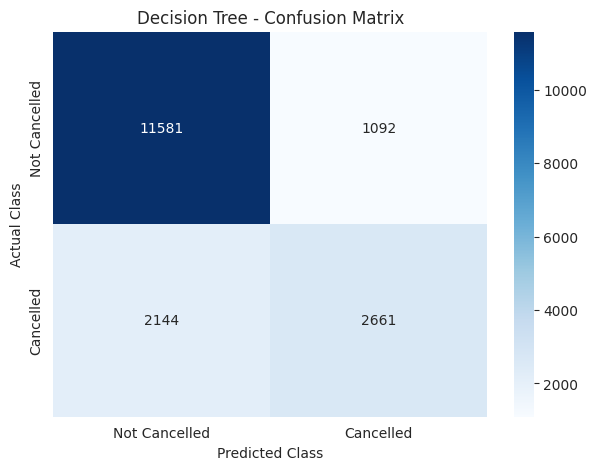

In [87]:
# Decision Tree confusion matrix

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Cancelled",
        "Cancelled"
    ],
    yticklabels=[
        "Not Cancelled",
        "Cancelled"
    ]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

#### 4.1.1 Findings



The Decision Tree achieved an accuracy of **81.49%**, which is higher than the Logistic Regression baseline of **79.01%**.

The Decision Tree also improved the other evaluation metrics:

- Precision increased from **67.45% to 70.90%**.
- Recall increased from **45.72% to 55.38%**.
- F1 Score increased from **54.50% to 62.19%**.
- ROC AUC increased from **83.25% to 86.86%**.

The largest improvement was observed in the Recall metric. The Decision Tree identified **55.38% of actual cancelled bookings**, compared with **45.72%** for Logistic Regression.

The classification report also shows that the Decision Tree performs better on the `Cancelled` class than the baseline. Its cancellation-class F1 Score increased to **0.62**, compared with **0.55** for Logistic Regression.

Overall, the Decision Tree provides a stronger predictive benchmark than Logistic Regression across all five evaluation metrics.

#### 4.1.2 Business Interpretation



From a hotel management perspective, the improvement in cancellation recall is particularly useful.

The Logistic Regression baseline detected approximately **46%** of actual cancellations, whereas the Decision Tree detected approximately **55%**.

This means the Decision Tree can identify a larger proportion of bookings that eventually become cancellations.

The improvement in Precision from **67.45% to 70.90%** is also beneficial because a greater proportion of the bookings flagged as potential cancellations are actually cancelled.

However, the model still fails to identify approximately **44.62%** of actual cancellations. Therefore, although the Decision Tree is better than the baseline, there is still room for improvement.

The Random Forest model will be trained next to determine whether an ensemble of decision trees can provide stronger and more stable predictions.

### 4.2 Model Progress Check



At this stage, two models have been evaluated:

1. Logistic Regression — baseline model
2. Decision Tree — nonlinear classification model

The Decision Tree currently performs better than Logistic Regression on:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

Therefore, the Decision Tree is currently the strongest model tested.

However, a final model cannot be selected yet because Random Forest still needs to be trained and evaluated.

### 4.3 Random Forest Classifier



Random Forest is an ensemble machine learning algorithm that combines multiple Decision Trees to produce a final prediction.

Instead of relying on one Decision Tree, Random Forest trains several trees using different subsets of the data and features. The individual tree predictions are then combined.

This approach can provide better generalization and reduce the risk of relying too heavily on the patterns learned by a single tree.

Random Forest is therefore included to determine whether an ensemble approach can improve cancellation prediction compared with Logistic Regression and the single Decision Tree.

RANDOM FOREST PIPELINE

In [88]:
# Create Random Forest pipeline

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


TRAIN RANDOM FOREST

In [89]:
# Train Random Forest

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


PREDICTIONS

In [90]:
# Generate Random Forest predictions

y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions generated successfully.
Number of predictions: 17478


RANDOM FOREST METRICS

In [91]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_roc_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

rf_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],
    "Score": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

rf_results["Score"] = rf_results["Score"].round(4)

display(rf_results)

,Metric,Score
0,Accuracy,0.8048
1,Precision,0.7863
2,Recall,0.3981
3,F1 Score,0.5286
4,ROC AUC,0.8746


CLASSIFICATION REPORT

In [92]:
# Random Forest classification report

print("Random Forest Classification Report")
print("=" * 55)

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Not Cancelled",
            "Cancelled"
        ]
    )
)

Random Forest Classification Report
               precision    recall  f1-score   support

Not Cancelled       0.81      0.96      0.88     12673
    Cancelled       0.79      0.40      0.53      4805

     accuracy                           0.80     17478
    macro avg       0.80      0.68      0.70     17478
 weighted avg       0.80      0.80      0.78     17478



CONFUSION MATRIX

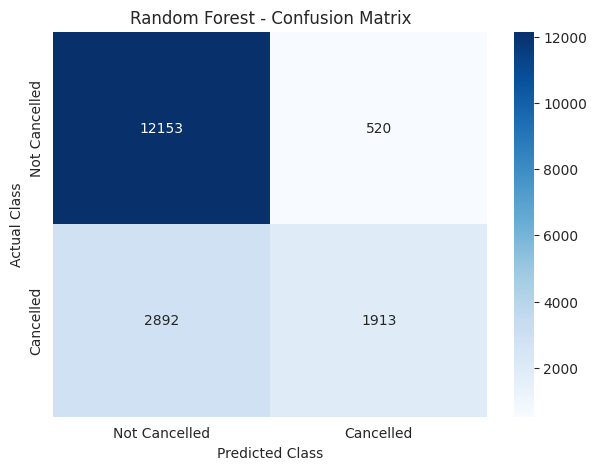

In [93]:
# Random Forest confusion matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Not Cancelled",
        "Cancelled"
    ],
    yticklabels=[
        "Not Cancelled",
        "Cancelled"
    ]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

#### 4.3.1 Findings



The Random Forest model achieved an overall accuracy of **80.48%** and a ROC AUC of **87.46%**.

The model achieved:

- Precision = **78.63%**
- Recall = **39.81%**
- F1 Score = **52.86%**
- ROC AUC = **87.46%**

The Random Forest achieved the **highest Precision and ROC AUC** among the three tested models. Its Precision of **78.63%** indicates that when the model predicts a booking as cancelled, the prediction is correct in a relatively high proportion of cases.

However, the model achieved a Recall of only **39.81%** for the `Cancelled` class. This means that the model identifies fewer than 40% of the bookings that actually become cancelled.

The confusion matrix shows:

- 12,153 bookings were correctly classified as Not Cancelled.
- 520 Not Cancelled bookings were incorrectly classified as Cancelled.
- 2,892 Cancelled bookings were incorrectly classified as Not Cancelled.
- 1,913 Cancelled bookings were correctly identified.

Therefore, although Random Forest has strong overall discrimination and precision, it does not provide the best cancellation detection performance when Recall and F1 Score are considered.

#### 4.3.2 Business Interpretation



For hotel management, the Random Forest model has an important advantage: its high Precision means that bookings flagged as potential cancellations are relatively reliable.

However, the model misses a large number of actual cancellations.

Out of **4,805 actual cancelled bookings**, the Random Forest correctly identifies **1,913** and incorrectly classifies **2,892** as Not Cancelled.

Therefore, Random Forest may be useful when the hotel wants to focus on a smaller group of bookings with a higher likelihood of cancellation, but it is less suitable when the primary objective is to identify as many potential cancellations as possible.

The model comparison will therefore consider multiple evaluation metrics rather than selecting a model based only on Accuracy or ROC AUC.

## 5. MODEL EVALUATION & COMPARISON

### 5.0 Introduction



Three classification models have now been trained and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

All three models were evaluated on the same unseen test dataset containing **17,478 observations**.

The models are compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

Using multiple metrics is important because the dataset is moderately imbalanced, with **72.51% Not Cancelled** and **27.49% Cancelled** bookings.

Therefore, Accuracy alone is not sufficient for selecting the most useful model.

COMPARISON TABLE

In [94]:
# Create a comparison table for all three models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1
    ],
    "ROC AUC": [
        logistic_roc_auc,
        tree_roc_auc,
        rf_roc_auc
    ]
})

# Convert scores to percentages for easier interpretation
model_comparison_display = model_comparison.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]:
    model_comparison_display[column] = (
        model_comparison_display[column] * 100
    ).round(2)

display(model_comparison_display)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,79.01,67.45,45.72,54.50,83.25
1,Decision Tree,81.49,70.90,55.38,62.19,86.86
2,Random Forest,80.48,78.63,39.81,52.86,87.46


### 5.1 Model Comparison Findings



The comparison shows that no single model achieves the highest value for every metric.

#### Logistic Regression

Logistic Regression provides the weakest overall performance among the three models. It achieves:

- Accuracy: **79.01%**
- Precision: **67.45%**
- Recall: **45.72%**
- F1 Score: **54.50%**
- ROC AUC: **83.25%**

It is useful as a baseline but is outperformed by the Decision Tree on all five reported metrics.

#### Decision Tree

The Decision Tree achieves the highest:

- Accuracy: **81.49%**
- Recall: **55.38%**
- F1 Score: **62.19%**

It also improves Precision and ROC AUC compared with Logistic Regression.

Most importantly, it provides the highest Recall for the `Cancelled` class. Therefore, it identifies more actual cancellation cases than the other two models.

#### Random Forest

Random Forest achieves the highest:

- Precision: **78.63%**
- ROC AUC: **87.46%**

However, its Recall is only **39.81%**, which is lower than both Logistic Regression and Decision Tree.

Its F1 Score of **52.86%** is also lower than the Decision Tree's **62.19%**.

Overall, the Decision Tree provides the best balance of Accuracy, Recall, and F1 Score for the cancellation prediction objective.

### 5.2 Best Model Selection



Based on the evaluation results, the **Decision Tree is selected as the preferred model for this task**.

The main reason is that the objective is to predict hotel booking cancellations, making the identification of actual cancelled bookings particularly important.

The Decision Tree achieves the highest Recall of **55.38%**, compared with:

- Logistic Regression: **45.72%**
- Random Forest: **39.81%**

It also achieves the highest F1 Score of **62.19%** and the highest Accuracy of **81.49%**.

Although Random Forest achieves a higher Precision of **78.63%** and ROC AUC of **87.46%**, its low Recall means that it misses a larger proportion of actual cancellations.

Therefore, the Decision Tree provides the strongest overall balance for the stated business objective.

The Random Forest result is still valuable because its high ROC AUC indicates strong overall ranking/discrimination ability, but its default classification threshold results in relatively low cancellation recall.

### 5.3 Visual Comparison of Model Performance



A visual comparison is created to make the differences between the three models easier to understand.

The chart compares Accuracy, Precision, Recall, F1 Score, and ROC AUC using the same test dataset.

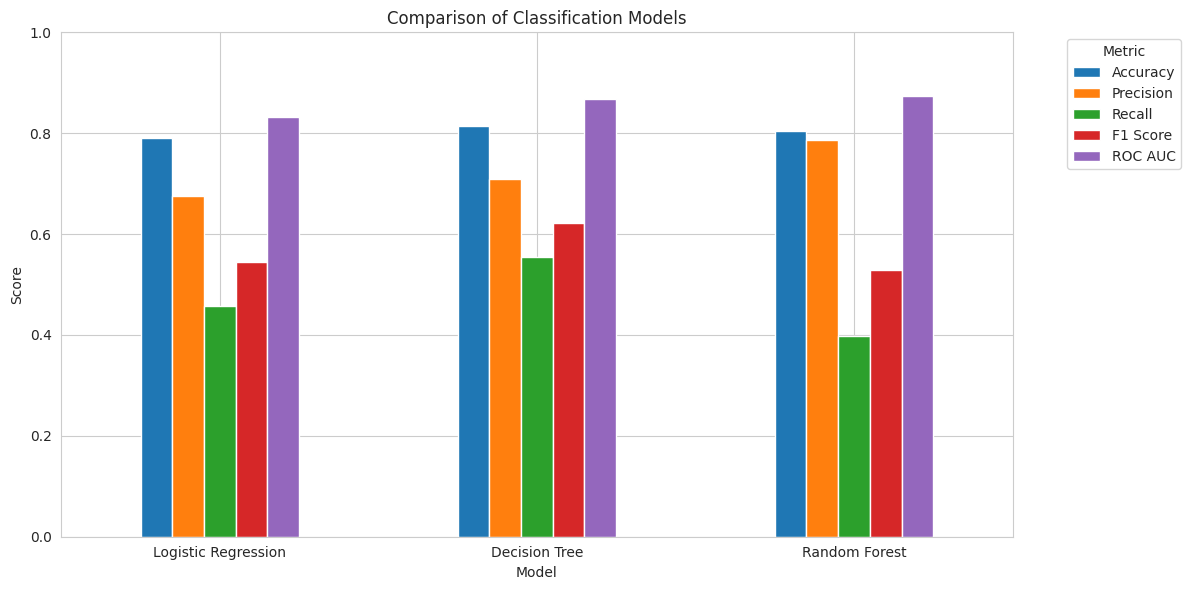

In [95]:
# Visual comparison of model performance

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

comparison_plot = model_comparison.set_index("Model")[metrics]

ax = comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### Findings

The visualization confirms the numerical comparison.

The Decision Tree demonstrates the strongest performance for **Recall and F1 Score**, which are important for identifying cancelled bookings.

Random Forest demonstrates the strongest **Precision and ROC AUC**, while Logistic Regression remains the weakest model across the major performance measures.

The visual comparison supports the selection of the Decision Tree as the preferred model for the current business objective.

## 6. OVERFITTING CHECK

### 6.1 Purpose





A machine learning model can achieve high performance on the training data while performing considerably worse on unseen data. This situation is known as **overfitting**.

Overfitting occurs when a model learns the training examples too closely instead of learning patterns that generalize to new observations.

To check for overfitting, the training and test performance of the Decision Tree and Random Forest models will be compared.

A relatively small difference between training and test performance suggests better generalization, while a large difference may indicate overfitting.

TRAINING PREDICTIONS

In [96]:
# Generate predictions on the training data

y_train_pred_tree = decision_tree_model.predict(X_train)
y_train_pred_rf = random_forest_model.predict(X_train)

print("Training predictions generated successfully.")

Training predictions generated successfully.


TRAIN VS TEST ACCURACY

In [97]:
# Calculate training and testing accuracy

tree_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_tree
)

tree_test_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

rf_train_accuracy = accuracy_score(
    y_train,
    y_train_pred_rf
)

rf_test_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

overfitting_accuracy = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Training Accuracy": [
        tree_train_accuracy,
        rf_train_accuracy
    ],
    "Test Accuracy": [
        tree_test_accuracy,
        rf_test_accuracy
    ]
})

overfitting_accuracy["Accuracy Gap"] = (
    overfitting_accuracy["Training Accuracy"]
    - overfitting_accuracy["Test Accuracy"]
)

overfitting_accuracy

,Model,Training Accuracy,Test Accuracy,Accuracy Gap
0,Decision Tree,0.821988,0.814853,0.007135
1,Random Forest,0.823032,0.804783,0.018249


F1 OVERFITTING CHECK

In [98]:
# Calculate training and testing F1 scores

tree_train_f1 = f1_score(
    y_train,
    y_train_pred_tree
)

tree_test_f1 = f1_score(
    y_test,
    y_pred_tree
)

rf_train_f1 = f1_score(
    y_train,
    y_train_pred_rf
)

rf_test_f1 = f1_score(
    y_test,
    y_pred_rf
)

overfitting_f1 = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Training F1": [
        tree_train_f1,
        rf_train_f1
    ],
    "Test F1": [
        tree_test_f1,
        rf_test_f1
    ]
})

overfitting_f1["F1 Gap"] = (
    overfitting_f1["Training F1"]
    - overfitting_f1["Test F1"]
)

overfitting_f1

,Model,Training F1,Test F1,F1 Gap
0,Decision Tree,0.637521,0.621874,0.015646
1,Random Forest,0.581433,0.528599,0.052834


### 6.2 Overfitting Results



The training and testing performance of the Decision Tree and Random Forest models was compared to assess their ability to generalize to unseen data.

#### Decision Tree

The Decision Tree achieved:

- Training Accuracy = **82.20%**
- Test Accuracy = **81.49%**
- Accuracy Gap = **0.71 percentage points**

For F1 Score:

- Training F1 = **63.75%**
- Test F1 = **62.19%**
- F1 Gap = **1.56 percentage points**

The small difference between training and test performance indicates that the Decision Tree generalizes relatively well to unseen data.

#### Random Forest

The Random Forest achieved:

- Training Accuracy = **82.30%**
- Test Accuracy = **80.48%**
- Accuracy Gap = **1.82 percentage points**

For F1 Score:

- Training F1 = **58.14%**
- Test F1 = **52.86%**
- F1 Gap = **5.28 percentage points**

The Random Forest shows a larger difference between training and test F1 performance compared with the Decision Tree. This indicates some degree of generalization loss, although the accuracy gap remains relatively small.

### 6.3 Findings



The overfitting analysis does not show severe overfitting in either model.

The **Decision Tree demonstrates the smallest performance gaps**, with an Accuracy Gap of only **0.71 percentage points** and an F1 Gap of **1.56 percentage points**.

This indicates that the Decision Tree's performance on the unseen test data is very close to its training performance.

The Random Forest has a slightly larger Accuracy Gap of **1.82 percentage points** and a larger F1 Gap of **5.28 percentage points**. This suggests that Random Forest experiences some additional generalization loss, particularly when evaluating the cancellation class using F1 Score.

Overall, both models show reasonable generalization, but the Decision Tree demonstrates more consistent training-to-test performance.

This finding further supports the selection of the Decision Tree as the preferred model for the current cancellation-prediction objective.

### 6.4 Training vs Testing Performance



The following visualization compares training and testing Accuracy and F1 Score for the Decision Tree and Random Forest models.

This provides a visual representation of the generalization gap between training and unseen test data.

In [99]:
# Prepare data for visualization

overfitting_plot = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Decision Tree",
        "Random Forest",
        "Random Forest"
    ],
    "Dataset": [
        "Training",
        "Testing",
        "Training",
        "Testing"
    ],
    "Accuracy": [
        tree_train_accuracy,
        tree_test_accuracy,
        rf_train_accuracy,
        rf_test_accuracy
    ],
    "F1 Score": [
        tree_train_f1,
        tree_test_f1,
        rf_train_f1,
        rf_test_f1
    ]
})

display(overfitting_plot)

,Model,Dataset,Accuracy,F1 Score
0,Decision Tree,Training,0.821988,0.637521
1,Decision Tree,Testing,0.814853,0.621874
2,Random Forest,Training,0.823032,0.581433
3,Random Forest,Testing,0.804783,0.528599


PLOTTING ACCURACY

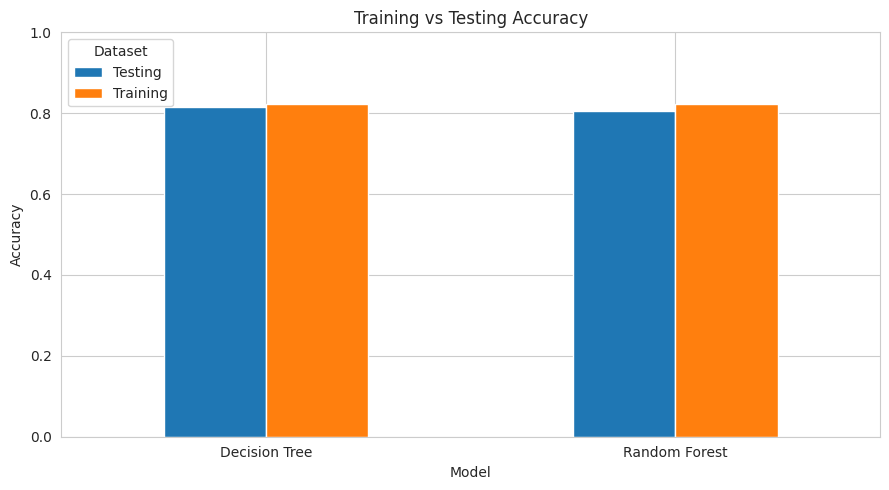

In [100]:
# Plot training vs testing accuracy

accuracy_plot = overfitting_plot.pivot(
    index="Model",
    columns="Dataset",
    values="Accuracy"
)

accuracy_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Training vs Testing Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Dataset")

plt.tight_layout()
plt.show()

PLOTTING F1

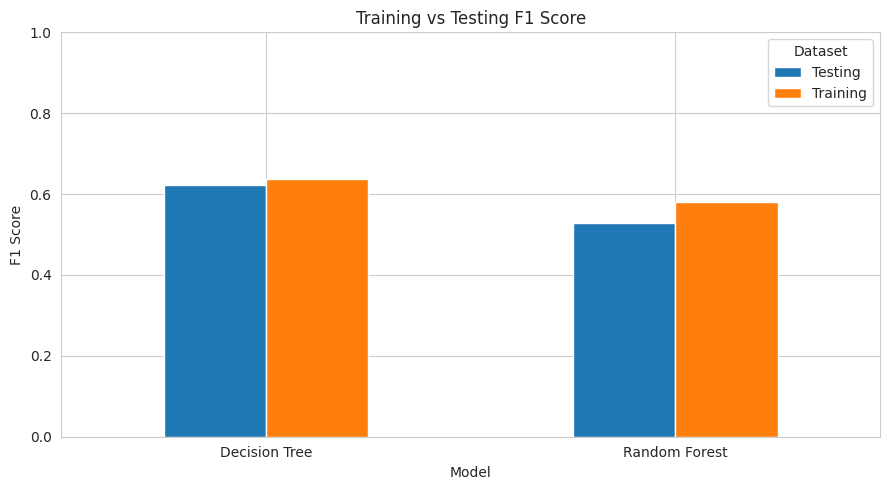

In [101]:
# Plot training vs testing F1 Score

f1_plot = overfitting_plot.pivot(
    index="Model",
    columns="Dataset",
    values="F1 Score"
)

f1_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Training vs Testing F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Dataset")

plt.tight_layout()
plt.show()

#### 6.5 Final Overfitting Conclusion



The comparison between training and testing performance shows that both models maintain relatively similar Accuracy on the training and test datasets.

The Decision Tree demonstrates the smallest performance gaps and therefore shows the most consistent generalization.

Random Forest shows a somewhat larger F1 gap, indicating greater variation between training and unseen test performance.

Overall, there is **no evidence of severe overfitting** in the evaluated models. The results indicate that the models are learning patterns that generalize reasonably well to the test dataset.

## 7. FEATURE IMPORTANCE

### 7.1 Purpose





Feature importance helps identify which input variables contribute most strongly to the predictions made by the selected Decision Tree model.

Understanding important features is useful because it provides interpretability and helps translate machine learning results into meaningful business insights.

For this project, the top 10 features will be identified based on the feature importance values calculated by the trained Decision Tree.

Higher feature importance indicates that the feature contributed more strongly to the model's decision-making process.

Feature importance should be interpreted as a measure of the model's reliance on a variable for prediction. It does not by itself prove that a feature causes booking cancellations.

EXTRACT FEATURE IMPORTANCE

In [102]:
# Extract the trained Decision Tree from the pipeline

trained_tree = decision_tree_model.named_steps["classifier"]

# Extract the preprocessing component
fitted_preprocessor = decision_tree_model.named_steps["preprocessor"]

# Get feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Decision Tree feature importance
feature_importances = trained_tree.feature_importances_

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Sort from highest to lowest importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display top 10
top_10_features = feature_importance_df.head(10)

display(top_10_features)

,Feature,Importance
0,cat__country_PRT,0.184133
1,num__total_of_special_requests,0.161510
2,num__lead_time,0.160533
3,cat__market_segment_Online TA,0.104370
4,num__required_car_parking_spaces,0.091270
5,num__arrival_date_year,0.060985
6,cat__deposit_type_Non Refund,0.042619
7,num__previous_cancellations,0.034316
8,cat__customer_type_Transient,0.026789
9,num__adr,0.025176


TOP 10 VISUALIZATION

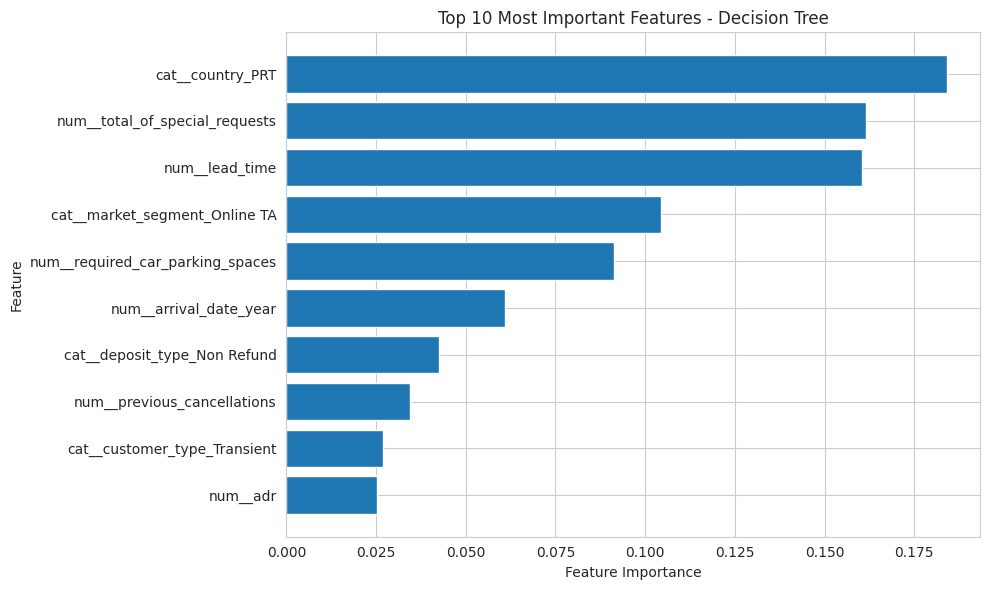

In [103]:
# Visualize the top 10 most important features

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_features["Feature"][::-1],
    top_10_features["Importance"][::-1]
)

plt.title("Top 10 Most Important Features - Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

#### Top 10 Feature Importance Results

The trained Decision Tree was used to identify the most important features contributing to its cancellation predictions.

The top 10 features identified by the model are:

| Rank | Feature | Importance |
|---:|---|---:|
| 1 | Country = PRT | 0.1841 |
| 2 | Total Special Requests | 0.1615 |
| 3 | Lead Time | 0.1605 |
| 4 | Market Segment = Online TA | 0.1044 |
| 5 | Required Car Parking Spaces | 0.0913 |
| 6 | Arrival Date Year | 0.0610 |
| 7 | Deposit Type = Non Refund | 0.0426 |
| 8 | Previous Cancellations | 0.0343 |
| 9 | Customer Type = Transient | 0.0268 |
| 10 | ADR | 0.0252 |

The feature names containing `cat__` and `num__` are generated by the preprocessing pipeline. The `cat__` prefix indicates a categorical feature, while `num__` indicates a numerical feature.

For example:

- `cat__country_PRT` represents the categorical condition **Country = PRT**.
- `cat__market_segment_Online TA` represents **Market Segment = Online TA**.
- `num__lead_time` represents the numerical **Lead Time** variable.

### 7.2 Feature Importance Findings



The feature-importance analysis shows that the Decision Tree relies on several booking characteristics when predicting cancellation.

The most important feature is **Country = PRT**, with an importance value of **0.1841**.

The next two most important features are **Total Special Requests** with an importance of **0.1615** and **Lead Time** with an importance of **0.1605**.

**Market Segment = Online TA** is also an important predictor, with an importance of **0.1044**.

Other important variables include:

- Required Car Parking Spaces: **0.0913**
- Arrival Date Year: **0.0610**
- Deposit Type = Non Refund: **0.0426**
- Previous Cancellations: **0.0343**
- Customer Type = Transient: **0.0268**
- ADR: **0.0252**

The results indicate that cancellation predictions are influenced by a combination of customer characteristics, booking behaviour, reservation conditions, and arrival information.

The importance values should be interpreted as the Decision Tree's reliance on these features for making predictions rather than as evidence that the features directly cause cancellations.

### 7.3 Key Features Identified by the Model



Three features stand out as particularly important in the Decision Tree:

#### 1. Country = PRT

`country_PRT` has the highest feature importance at **0.1841**.

This means that the Decision Tree makes substantial use of whether the booking's country category is PRT when distinguishing between cancelled and non-cancelled bookings.

#### 2. Total Special Requests

`total_of_special_requests` has an importance of **0.1615**.

This indicates that the number of special requests associated with a booking provides substantial predictive information for the model.

#### 3. Lead Time

`lead_time` has an importance of **0.1605**.

Lead time represents the booking-related time interval captured in the dataset and is one of the strongest numerical predictors used by the Decision Tree.

Together, these results show that booking characteristics and customer/reservation information contain useful signals for predicting cancellation.

### 7.4 Business Interpretation



The feature-importance results provide useful direction for hotel management.

The model suggests that particular booking characteristics should receive more attention when assessing cancellation risk.

For example, **Lead Time**, **Deposit Type**, **Previous Cancellations**, and **Market Segment** can potentially be incorporated into a booking-risk monitoring process.

The importance of **Total Special Requests** also indicates that reservation-level details may provide useful information when assessing cancellation patterns.

However, these results should be treated as predictive insights rather than causal conclusions. Further analysis would be required before implementing policies based on any individual feature.

The feature-importance analysis can therefore be used to support targeted monitoring and business decision-making while avoiding unsupported assumptions about why customers cancel.

##### Technical Note

The feature importance values were extracted from the trained Decision Tree after preprocessing.

Categorical variables were transformed into encoded features by the preprocessing pipeline. As a result, some original categorical variables appear as individual encoded categories, such as:

- `country_PRT`
- `market_segment_Online TA`
- `deposit_type_Non Refund`
- `customer_type_Transient`

Therefore, the importance value shown for an encoded categorical feature represents that specific encoded category rather than necessarily representing the entire original categorical variable.

## 8. REQUIRED BUSINESS QUESTIONS

### 8.0 Introduction


This section answers the eight required questions for the Week 2 machine learning task.

The answers are based on:

- The prepared hotel booking dataset
- Exploratory analysis performed during preparation
- Logistic Regression, Decision Tree, and Random Forest models
- Unseen test-set evaluation
- Overfitting analysis
- Decision Tree feature importance analysis

The purpose of this section is to connect the technical machine learning results with the practical business problem of predicting hotel booking cancellations.

### 8.1 Question 1: Why did you choose `is_canceled` as the target?



#### Answer

The target variable was chosen as `is_canceled` because the main objective of the project is to predict whether a hotel booking will be cancelled.

The `is_canceled` variable is a binary outcome:

- `0` = Not Cancelled
- `1` = Cancelled

This makes the problem a **binary classification problem**.

Predicting cancellations is useful for hotel management because unexpected cancellations can affect room occupancy, revenue planning, staffing, and inventory management.

By predicting cancellation risk before the arrival date, hotel management can identify potentially risky bookings and take appropriate actions.

Therefore, `is_canceled` directly represents the business outcome that the machine learning model is intended to predict.

### 8.2 Question 2: Which columns did you remove before modeling and why?



#### Answer

Six columns were removed before model training:

1. `reservation_status`
2. `reservation_status_date`
3. `assigned_room_type`
4. `room_type_changed`
5. `booking_changes`
6. `agent`

The original dataset contained **36 columns**. After removing these six columns, the modeling dataset contained **30 columns**, including the target variable.

##### Reasons for removal

**1. `reservation_status`**

This column describes the final reservation status and is directly related to the outcome of the booking. Using it could introduce information that would only be known after the reservation outcome, resulting in target leakage.

**2. `reservation_status_date`**

This records the date associated with the final reservation status and is closely connected to the final outcome. It was therefore removed to avoid using post-outcome information.

**3. `assigned_room_type`**

The assigned room type may reflect changes or decisions made during the reservation process and can contain information that is not necessarily available at the initial prediction stage.

**4. `room_type_changed`**

This feature describes whether the room type changed during the booking process. Such changes may occur after the original booking and therefore may not be appropriate for an early cancellation prediction model.

**5. `booking_changes`**

This variable represents changes made to a booking. Some changes can occur after the original reservation and may provide information that becomes available later in the booking lifecycle.

**6. `agent`**

The `agent` field identifies the booking agent or channel identifier. It was removed as part of the modeling preparation to simplify the feature set and avoid relying on a highly specific identifier.

The goal of removing these variables was to create a cleaner modeling dataset and reduce the possibility of information leakage or inappropriate post-booking information influencing predictions.

### 8.3 Question 3: Why is accuracy alone not enough for this problem?



#### Answer

Accuracy alone is not sufficient because the target variable is imbalanced.

The dataset contains:

- **63,364 Not Cancelled bookings (72.51%)**
- **24,025 Cancelled bookings (27.49%)**

Because Not Cancelled bookings represent the majority class, a model could achieve relatively high accuracy by predicting the majority class frequently while still failing to identify many actual cancellations.

For this reason, additional metrics were used:

- **Precision** – measures how many predicted cancellations were actually cancellations.
- **Recall** – measures how many actual cancellations were successfully identified.
- **F1 Score** – balances Precision and Recall.
- **ROC AUC** – measures the model's ability to distinguish between cancelled and non-cancelled bookings across classification thresholds.

Therefore, model performance should be evaluated using multiple metrics rather than Accuracy alone.

### 8.4 Question 4: Which model performed best on unseen test data, and why?



#### Answer

Based on the overall evaluation and the business objective, the **Decision Tree performed best on the unseen test data**.

The test-set results were:

| Model | Accuracy | Precision | Recall | F1 Score | ROC AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 79.01% | 67.45% | 45.72% | 54.50% | 83.25% |
| Decision Tree | **81.49%** | 70.90% | **55.38%** | **62.19%** | 86.86% |
| Random Forest | 80.48% | **78.63%** | 39.81% | 52.86% | **87.46% |

The Decision Tree achieved the highest Accuracy, Recall, and F1 Score.

Its Recall of **55.38%** is particularly important because the business problem involves identifying bookings that may be cancelled.

Although Random Forest achieved higher Precision and ROC AUC, its Recall was only **39.81%**, meaning that it missed a larger proportion of actual cancellations.

Therefore, the Decision Tree was selected as the preferred model because it provides the strongest overall balance for the current business objective.

### 8.5 Question 5: Which model showed the most overfitting?



#### Answer

The **Random Forest showed more overfitting than the Decision Tree** based on the difference between training and test performance.

The results were:

| Model | Accuracy Gap | F1 Gap |
|---|---:|---:|
| Decision Tree | **0.71 percentage points** | **1.56 percentage points** |
| Random Forest | 1.82 percentage points | **5.28 percentage points** |

The Decision Tree had very similar training and test performance.

Its training Accuracy was **82.20%**, while test Accuracy was **81.49%**.

Its training F1 Score was **63.75%**, while test F1 Score was **62.19%**.

Random Forest had a larger F1 gap of **5.28 percentage points**, indicating greater loss in performance when moving from training data to unseen data.

Therefore, Random Forest showed more evidence of overfitting/generalization loss than the Decision Tree.

However, neither model showed severe overfitting based on the observed Accuracy gaps.

### 8.6 Question 6: Which metric is most useful for the hotel, and why?



#### Answer

For this business problem, **Recall for the Cancelled class is the most useful primary metric**.

Recall answers the question:

> "Of all bookings that actually get cancelled, how many did the model successfully identify?"

The Decision Tree achieved a cancellation Recall of **55.38%**.

This means the model correctly identifies approximately 55 out of every 100 actual cancelled bookings in the test data.

Recall is particularly important because missing a potentially cancelled booking can have business consequences for the hotel, such as unexpected vacant rooms, inaccurate occupancy planning, and difficulty managing inventory.

However, Recall should not be considered in isolation. Precision and F1 Score should also be monitored because increasing Recall can result in more false cancellation alerts.

Therefore, the recommended evaluation approach is:

**Primary metric: Recall**

**Supporting metrics: F1 Score, Precision, Accuracy, and ROC AUC**

### 8.7 Question 7: What are the three most important features in your best model?



#### Answer

The three most important features identified by the selected Decision Tree model are:

| Rank | Feature | Importance |
|---:|---|---:|
| 1 | `country_PRT` | 0.1841 |
| 2 | `total_of_special_requests` | 0.1615 |
| 3 | `lead_time` | 0.1605 |

### Interpretation

**1. Country = PRT**

This is the most important feature in the Decision Tree, with an importance value of **0.1841**. The model makes substantial use of this encoded country category when making cancellation predictions.

**2. Total Special Requests**

This feature has an importance of **0.1615**. The number of special requests associated with a booking provides significant predictive information for the model.

**3. Lead Time**

This feature has an importance of **0.1605** and is the third most important feature. It represents the booking lead-time information and provides substantial predictive information for cancellation classification.

These features are important predictors used by the model, but their importance does not mean that they directly cause customers to cancel their bookings.

### 8.8 Question 8: Would you trust the model for real business use today?



#### Answer

**No, I would not deploy the model directly into real business operations today.**

The model demonstrates promising predictive performance, but additional validation and testing would be required before production deployment.

The Decision Tree achieved:

- Accuracy = **81.49%**
- Precision = **70.90%**
- Recall = **55.38%**
- F1 Score = **62.19%**
- ROC AUC = **86.86%**

These results indicate that the model has useful predictive capability. However, the model still misses a considerable proportion of actual cancellations.

In addition, the model was evaluated using a single train-test split from the available dataset. Before real-world deployment, the model should be tested using additional validation data and, ideally, future booking data.

The model should also be monitored after deployment because hotel booking patterns, customer behaviour, market segments, and external conditions can change over time.

Before production use, I would recommend:

1. Additional validation using cross-validation or future/time-based test data.
2. Testing the model on new real-world booking data.
3. Evaluating different classification thresholds to improve cancellation Recall if required.
4. Monitoring model performance after deployment.
5. Checking whether model performance remains consistent across important customer and booking groups.
6. Establishing a process for retraining the model when booking patterns change.

Therefore, the current model should be considered a **promising prototype rather than a fully production-ready business system**.

### 8.9 Summary of Answers



|  | Business Question | Final Answer |
|---:|---|---|
| 1 | Why `is_canceled`? | It directly represents the business outcome of booking cancellation and creates a binary classification problem. |
| 2 | Which columns were removed? | `reservation_status`, `reservation_status_date`, `assigned_room_type`, `room_type_changed`, `booking_changes`, and `agent`. |
| 3 | Why not Accuracy alone? | The target is imbalanced, so Accuracy can hide poor cancellation detection. |
| 4 | Best model? | **Decision Tree**, based on the strongest overall balance of Accuracy, Recall, and F1 Score. |
| 5 | Most overfitting? | **Random Forest**, particularly based on its larger F1 training-test gap of 5.28 percentage points. |
| 6 | Most useful metric? | **Recall**, because identifying actual cancellations is important to hotel planning. |
| 7 | Top 3 features? | `country_PRT`, `total_of_special_requests`, and `lead_time`. |
| 8 | Trust for real business today? | **No.** It is promising but requires additional validation, threshold analysis, monitoring, and real-world testing. |

##9. BUSINESS RECOMMENDATIONS

### 9.0 Introduction



The machine learning analysis provides several findings that can be translated into practical recommendations for hotel management.

The selected Decision Tree model achieved:

- Accuracy: 81.49%
- Precision: 70.90%
- Recall: 55.38%
- F1 Score: 62.19%
- ROC AUC: 86.86%

The analysis also identified important predictive features, including:

1. Country = PRT
2. Total Special Requests
3. Lead Time
4. Market Segment = Online TA
5. Required Car Parking Spaces
6. Arrival Date Year
7. Deposit Type = Non Refund
8. Previous Cancellations
9. Customer Type = Transient
10. ADR

These findings can support hotel management in identifying potentially risky bookings and improving reservation planning.

The recommendations below are based on the observed model results. They should be treated as decision-support recommendations rather than automatic business rules.

### 9.1 Recommendations

#### 9.1.1 Recommendation 1: Use the Model for Cancellation Risk Screening



The hotel should consider using the selected Decision Tree model as a **cancellation-risk screening tool** rather than as an automatic decision-making system.

The model achieved a cancellation Recall of **55.38%**, meaning that it successfully identified more than half of the actual cancelled bookings in the test dataset.

This indicates that the model can provide useful signals about which bookings may require additional attention.

##### Suggested business process

1. A new booking is entered into the hotel reservation system.
2. Relevant booking information is provided to the prediction model.
3. The model generates a cancellation-risk prediction.
4. Potentially risky bookings are flagged for monitoring.
5. Hotel staff review the booking before taking any action.
6. The hotel can use appropriate reservation-management strategies for higher-risk bookings.

The model should therefore support human decision-making rather than replace it.

##### Expected benefit

Early identification of potentially risky bookings can help the hotel improve occupancy planning, reservation monitoring, and inventory management.

#### 9.1.2 Recommendation 2: Monitor Booking Lead Time



`lead_time` was the **third most important feature** in the Decision Tree, with an importance value of **0.1605**.

This indicates that lead-time information provides substantial predictive information for the cancellation model.

##### Business recommendation

Hotel management should monitor booking lead-time patterns when assessing reservation risk.

Bookings with different lead-time characteristics may have different cancellation patterns. Therefore, lead time can be incorporated into a reservation-risk monitoring process.

For example, the hotel could:

- Monitor cancellation patterns across different lead-time ranges.
- Include lead time in reservation-risk dashboards.
- Use lead-time information when planning room inventory.
- Compare predicted cancellation risk with actual cancellation outcomes over time.

##### Important limitation

The feature importance result does not establish that lead time directly causes cancellation. It only shows that the model relied heavily on this feature when making predictions.

#### 9.1.3 Recommendation 3: Monitor Important Booking Characteristics



The Decision Tree identified several categorical and booking-related variables among the most important predictors.

These include:

- `country_PRT` — importance: **0.1841**
- `market_segment_Online TA` — importance: **0.1044**
- `deposit_type_Non Refund` — importance: **0.0426**
- `customer_type_Transient` — importance: **0.0268**
- `previous_cancellations` — importance: **0.0343**

These variables can be incorporated into hotel management's analytical monitoring process.

##### Business recommendation

The hotel should monitor cancellation rates across different booking characteristics rather than treating all bookings identically.

Useful monitoring categories may include:

- Customer origin/country
- Market segment
- Deposit type
- Customer type
- Previous cancellation history

This can help management understand where cancellation risk is concentrated within the hotel's booking data.

However, these categories should be used for **monitoring and analysis**, not as automatic reasons to reject or penalize a customer.

#### 9.1.4 Recommendation 4: Consider Special Requests in Reservation Analysis



`total_of_special_requests` was the **second most important feature** in the Decision Tree, with an importance value of **0.1615**.

This suggests that the number of special requests associated with a booking provides substantial predictive information for the model.

##### Business recommendation

The hotel can include the number of special requests as one of the variables monitored in reservation analysis.

For example, management could:

- Monitor cancellation rates by number of special requests.
- Include special-request information in internal booking dashboards.
- Compare predicted cancellation risk with actual outcomes.
- Investigate whether different reservation patterns are associated with different cancellation rates.

This feature should be treated as a predictive signal rather than a direct explanation for why a customer cancels.

#### 9.1.5 Recommendation 5: Monitor Previous Cancellation History



`previous_cancellations` appeared among the top 10 important features, with an importance value of **0.0343**.

This indicates that previous cancellation history provides some predictive information to the Decision Tree.

##### Business recommendation

The hotel can use previous cancellation history as one component of a broader reservation-risk assessment.

Instead of using previous cancellations as a standalone decision rule, it should be combined with other booking characteristics and the model's overall prediction.

This could help reservation teams identify bookings that may require closer monitoring.

Any customer-facing action should be based on appropriate hotel policies and should not rely solely on the model's prediction.

#### 9.1.6 Recommendation 6: Keep Human Oversight in the Decision Process



The current model should not be used to automatically reject bookings, change prices, or penalize customers based only on predicted cancellation risk.

The model is a predictive tool and does not establish why a customer will cancel.

For example, feature importance indicates that `country_PRT` is the strongest individual encoded feature in the model. However, this does not mean that customers from a particular country are inherently more likely to cancel or should receive different treatment.

Therefore, the model should be used to support internal planning and monitoring while keeping human oversight in the decision process.

This approach reduces the risk of making unsupported business decisions based solely on statistical predictions.

#### 9.1.7 Recommendation 7: Improve and Validate the Model Before Production Use



The current Decision Tree provides useful predictive performance, but it should not be considered production-ready.

The model achieved a cancellation Recall of **55.38%**, meaning that a significant number of actual cancellations were still not identified.

Before deployment, the hotel should consider:

1. Testing the model using additional unseen data.
2. Using cross-validation to assess model stability.
3. Testing future booking data to evaluate real-world generalization.
4. Investigating different probability thresholds.
5. Comparing additional machine learning models.
6. Monitoring Precision and Recall after deployment.
7. Retraining the model when booking patterns change.

The model should first be implemented as a controlled decision-support prototype and evaluated using real operational data.

#### 9.1.8 Recommendation 8: Develop a Cancellation Risk Dashboard



A future implementation could provide hotel management with a simple cancellation-risk dashboard.

The dashboard could display:

- Total bookings
- Predicted high-risk bookings
- Predicted low-risk bookings
- Actual cancellations
- Cancellation rate
- Model Recall
- Model Precision
- Model F1 Score
- Cancellation trends over time
- Cancellation patterns by market segment
- Cancellation patterns by lead-time range
- Cancellation patterns by deposit type

This would allow management to monitor both booking activity and model performance.

The dashboard should also distinguish between model predictions and actual outcomes so that the hotel can continuously evaluate whether the model remains useful.

### 9.2 Expected Business Impact



If implemented carefully, the proposed approach could support the hotel in several areas:

#### 1. Better Occupancy Planning

Identifying potentially risky bookings earlier can help management anticipate possible changes in occupancy.

#### 2. Improved Reservation Monitoring

High-risk bookings can be prioritized for review instead of treating every reservation equally.

#### 3. Better Inventory Management

More informed cancellation estimates can support room inventory and availability planning.

#### 4. Data-Driven Decision Making

The model provides a quantitative approach for identifying booking patterns associated with cancellation predictions.

#### 5. Continuous Performance Monitoring

Tracking predictions against actual cancellations allows the hotel to determine whether the model remains effective over time.

The model should therefore be viewed as a **decision-support tool** that can complement existing hotel reservation and management processes.

### 9.3 Business Recommendation Summary



| Recommendation | Evidence from Analysis | Proposed Action |
|---|---|---|
| Cancellation-risk screening | Decision Tree Recall = 55.38% | Use the model as an early-warning tool |
| Monitor lead time | Importance = 0.1605 | Include lead time in reservation-risk monitoring |
| Monitor booking characteristics | Several categorical features appear in Top 10 | Analyze cancellation patterns by booking characteristics |
| Monitor special requests | Importance = 0.1615 | Include special-request patterns in analysis |
| Monitor previous cancellations | Importance = 0.0343 | Consider cancellation history as one risk signal |
| Maintain human oversight | Model is predictive, not causal | Do not automatically reject or penalize bookings |
| Validate before deployment | Recall = 55.38% | Perform additional validation and real-world testing |
| Build a dashboard | Multiple useful metrics and features identified | Monitor predictions and actual cancellations over time |

### 9.4 Overall Business Recommendation



Based on the Week 2 analysis, the hotel can benefit from using machine learning as a **cancellation-risk decision-support system**.

The Decision Tree was selected as the preferred model because it provided the strongest overall balance of test Accuracy, Recall, and F1 Score among the evaluated models. However, its Recall of **55.38%** also shows that the model does not identify all actual cancellations.

Therefore, the recommended approach is not immediate full automation. Instead, the hotel should first use the model as an internal screening and monitoring tool, validate it on additional real-world data, and continuously monitor its performance.

The most important predictive signals identified by the model, particularly `country_PRT`, `total_of_special_requests`, and `lead_time`, can be incorporated into further analysis and reservation monitoring.

Overall, the model demonstrates **promising business potential**, but additional validation and improvement are required before production deployment.

## 10. FINAL MODEL SELECTION

### 10.0 Introduction



This section selects the final machine learning model for the hotel booking cancellation prediction task.

The three evaluated classification models were:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The final model is selected using:

- Test-set performance
- Cancellation Recall
- F1 Score
- Accuracy
- ROC AUC
- Generalization between training and testing data
- Business requirements
- Model interpretability

The goal is not simply to select the model with the highest Accuracy. The selected model should provide a useful balance between predictive performance, cancellation detection, generalization, and interpretability.

###10.1 Model Performance Comparison

In [104]:
# Final comparison of all evaluated models

final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.7901,
        0.8149,
        0.8048
    ],
    "Precision": [
        0.6745,
        0.7090,
        0.7863
    ],
    "Recall": [
        0.4572,
        0.5538,
        0.3981
    ],
    "F1 Score": [
        0.5450,
        0.6219,
        0.5286
    ],
    "ROC AUC": [
        0.8325,
        0.8686,
        0.8746
    ]
})

display(final_model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7901,0.6745,0.4572,0.5450,0.8325
1,Decision Tree,0.8149,0.7090,0.5538,0.6219,0.8686
2,Random Forest,0.8048,0.7863,0.3981,0.5286,0.8746


### 10.2 Model Selection Findings


The comparison shows that the three models have different strengths.

#### Logistic Regression

Logistic Regression achieved:

- Accuracy = 79.01%
- Precision = 67.45%
- Recall = 45.72%
- F1 Score = 54.50%
- ROC AUC = 83.25%

It provides a reasonable baseline but performs below the two tree-based models on the main classification metrics.

##### Decision Tree

Decision Tree achieved:

- Accuracy = **81.49%**
- Precision = **70.90%**
- Recall = **55.38%**
- F1 Score = **62.19%**
- ROC AUC = **86.86%**

It achieved the highest Accuracy, Recall, and F1 Score among the three evaluated models.

### Random Forest

Random Forest achieved:

- Accuracy = 80.48%
- Precision = **78.63%**
- Recall = 39.81%
- F1 Score = 52.86%
- ROC AUC = **87.46%**

Random Forest achieved the highest Precision and ROC AUC. However, its cancellation Recall was considerably lower than the Decision Tree.

Since identifying actual cancellations is an important objective for the hotel, Recall and F1 Score are particularly important when selecting the final model.

### 10.3 Selected Final Model: Decision Tree



The **Decision Tree** is selected as the final model for the current Week 2 task.

The Decision Tree was selected because it provides the strongest overall balance between the evaluation metrics that are important for this business problem.

Its test-set performance was:

- **Accuracy: 81.49%**
- **Precision: 70.90%**
- **Recall: 55.38%**
- **F1 Score: 62.19%**
- **ROC AUC: 86.86%**

The Decision Tree achieved the highest Accuracy, Recall, and F1 Score among the evaluated models.

Most importantly, it achieved the highest Recall for the cancellation class. This means it identified a larger proportion of the actual cancelled bookings than the other evaluated models.

The model also demonstrated relatively small training-to-test performance gaps:

- Accuracy Gap = **0.71 percentage points**
- F1 Gap = **1.56 percentage points**

This indicates relatively consistent performance between the training and unseen test data.

Therefore, the Decision Tree is selected as the preferred model for the current business objective.

### 10.4 Why Was Random Forest Not Selected?



Random Forest achieved the highest ROC AUC (**87.46%**) and Precision (**78.63%**).

However, it achieved a substantially lower cancellation Recall of **39.81%**, compared with **55.38%** for the Decision Tree.

For the current business objective, missing actual cancellations is an important concern.

The Random Forest also showed a larger training-to-test F1 gap:

- Random Forest F1 Gap = **5.28 percentage points**
- Decision Tree F1 Gap = **1.56 percentage points**

Therefore, although Random Forest is strong in terms of discrimination and precision, the Decision Tree provides a better balance for the current cancellation-detection objective and demonstrates more consistent training-to-test performance.

### 10.5 Final Model Characteristics



The selected Decision Tree provides several useful characteristics for this project.

#### Predictive Performance

The model achieved an Accuracy of **81.49%** and an F1 Score of **62.19%** on unseen test data.

#### Cancellation Detection

The model achieved a cancellation Recall of **55.38%**, making it the strongest of the evaluated models for identifying actual cancellations.

#### Generalization

The model showed relatively small differences between training and test performance.

#### Interpretability

Decision Trees are relatively interpretable because their predictions can be represented through decision rules and feature importance.

#### Business Suitability

The model can therefore serve as a useful prototype for cancellation-risk screening and business analysis.

However, it should not yet be considered a fully production-ready system.

### 10.6 Model Limitations



Although the Decision Tree provides promising results, several limitations should be considered.

#### 1. Recall is not perfect

The cancellation Recall is **55.38%**, meaning that a considerable proportion of actual cancellations are still missed by the model.

#### 2. The dataset is imbalanced

The dataset contains 72.51% non-cancelled bookings and 27.49% cancelled bookings.

Therefore, multiple evaluation metrics are necessary to properly assess model performance.

#### 3. Test performance does not guarantee real-world performance

The model was evaluated on an unseen test split from the available dataset. Performance on future hotel bookings may differ.

#### 4. Additional validation is required

Cross-validation and future/time-based validation could provide stronger evidence about model stability.

#### 5. Feature importance does not establish causation

The important features identified by the Decision Tree indicate predictive usefulness, but they do not prove that those variables cause cancellations.

#### 6. Production deployment requires monitoring

If used in a real hotel environment, the model would need continuous monitoring and periodic retraining because booking patterns can change over time.

### 10.7 Final Selection Statement



Based on the evaluation performed in this project, the **Decision Tree is selected as the final model** for hotel booking cancellation prediction.

The selection is based primarily on its stronger cancellation Recall (**55.38%**), highest F1 Score (**62.19%**), highest test Accuracy (**81.49%**), and relatively small training-to-test performance gaps.

Random Forest achieved a slightly higher ROC AUC (**87.46%**) and Precision (**78.63%**), but its cancellation Recall was considerably lower (**39.81%**).

Therefore, the Decision Tree provides the most appropriate overall balance for the current business objective.

The selected model should initially be treated as a **prototype decision-support model** rather than a fully automated production system. Additional validation using future and real-world booking data is recommended before deployment.

###10.8 Optional: Create a Final Model Selection Card

In [105]:
from IPython.display import display, Markdown

display(Markdown("""
###  FINAL MODEL

**Selected Model:** Decision Tree

| Metric | Test Score |
|---|---:|
| Accuracy | **81.49%** |
| Precision | **70.90%** |
| Recall | **55.38%** |
| F1 Score | **62.19%** |
| ROC AUC | **86.86%** |

**Reason for Selection:**
Strongest overall balance of Accuracy, Recall, and F1 Score, with relatively small training-to-test performance gaps.

**Status:** Prototype / Decision-Support Model
"""))


###  FINAL MODEL

**Selected Model:** Decision Tree

| Metric | Test Score |
|---|---:|
| Accuracy | **81.49%** |
| Precision | **70.90%** |
| Recall | **55.38%** |
| F1 Score | **62.19%** |
| ROC AUC | **86.86%** |

**Reason for Selection:**  
Strongest overall balance of Accuracy, Recall, and F1 Score, with relatively small training-to-test performance gaps.

**Status:** Prototype / Decision-Support Model


In [106]:
# Check the type and structure of the selected model

print("Selected model variable:")
print(decision_tree_model)

print("\nModel type:")
print(type(decision_tree_model))

Selected model variable:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                   

##11. MODEL EXPORT

### 11.0 Introduction



The selected Decision Tree model is now ready to be exported for future use.

The complete trained pipeline will be saved rather than only the Decision Tree classifier.

The pipeline contains:

1. Numerical feature preprocessing
2. Categorical feature preprocessing
3. Missing-value handling
4. Feature scaling
5. One-hot encoding
6. The trained Decision Tree classifier

Saving the complete pipeline ensures that the same preprocessing steps used during model training are automatically applied when the model is loaded and used for future predictions.

The exported model will be saved as a `.pkl` file using Python's `joblib` library.

###11.1 Save the Final Model

In [107]:
import joblib
import os

# Define the output filename
model_filename = "hotel_cancellation_decision_tree.pkl"

# Save the complete trained pipeline
joblib.dump(decision_tree_model, model_filename)

print("Model saved successfully.")
print("File name:", model_filename)
print("File size:", round(os.path.getsize(model_filename) / 1024, 2), "KB")

Model saved successfully.
File name: hotel_cancellation_decision_tree.pkl
File size: 52.93 KB


###11.2 Verify That the Model Exists

In [108]:
# Verify that the model file exists

if os.path.exists(model_filename):
    print("✓ Model file exists.")
    print("✓ File is ready for download and future use.")
else:
    print("✗ Model file was not found.")

✓ Model file exists.
✓ File is ready for download and future use.


#### Findings

The trained Decision Tree pipeline was successfully saved as:

`hotel_cancellation_decision_tree.pkl`

The exported file contains the complete preprocessing and classification pipeline, allowing the same transformations used during training to be applied when making future predictions.

###11.3 Test the Saved Model

In [109]:
# Load the saved model

loaded_model = joblib.load(model_filename)

print("Saved model loaded successfully.")
print("Loaded model type:")
print(type(loaded_model))

Saved model loaded successfully.
Loaded model type:
<class 'sklearn.pipeline.Pipeline'>


### 11.4 Verify Predictions from the Saved Model

In [110]:
# Generate predictions using the loaded model

loaded_predictions = loaded_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(loaded_predictions))

Predictions generated successfully.
Number of predictions: 17478


###11.5 Compare Original and Loaded Model Predictions

In [111]:
# Compare predictions from the original and loaded models

predictions_match = (y_pred_tree == loaded_predictions).all()

print("Original and loaded model predictions match:", predictions_match)

if predictions_match:
    print("✓ Model export verification successful.")
else:
    print("✗ Model predictions do not match.")

Original and loaded model predictions match: True
✓ Model export verification successful.


###11.6 Export the Model Comparison Table

In [112]:
# Save the final model comparison table

comparison_filename = "hotel_model_comparison.csv"

final_model_comparison.to_csv(
    comparison_filename,
    index=False
)

print("Model comparison saved successfully.")
print("File name:", comparison_filename)

Model comparison saved successfully.
File name: hotel_model_comparison.csv


###11.7 Display the Saved Comparison File

In [113]:
# Read the saved comparison file and verify its contents

comparison_check = pd.read_csv(comparison_filename)

display(comparison_check)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7901,0.6745,0.4572,0.5450,0.8325
1,Decision Tree,0.8149,0.7090,0.5538,0.6219,0.8686
2,Random Forest,0.8048,0.7863,0.3981,0.5286,0.8746


#### Findings

The final model comparison has been exported successfully as:

`hotel_model_comparison.csv`

The file contains the test-set performance of Logistic Regression, Decision Tree, and Random Forest using Accuracy, Precision, Recall, F1 Score, and ROC AUC.

This file provides a compact summary of the model-selection process and can be used as a supporting project artifact.

###11.8 Export the Modeling Dataset

In [114]:
# Save the modeling dataset

dataset_filename = "hotel_booking_modeling_dataset.csv"

modeling_df.to_csv(
    dataset_filename,
    index=False
)

print("Modeling dataset saved successfully.")
print("File name:", dataset_filename)
print("Shape:", modeling_df.shape)

Modeling dataset saved successfully.
File name: hotel_booking_modeling_dataset.csv
Shape: (87389, 30)


###11.9 Verify the Modeling Dataset

In [115]:
# Verify the exported modeling dataset

dataset_check = pd.read_csv(dataset_filename)

print("Dataset loaded successfully.")
print("Rows:", dataset_check.shape[0])
print("Columns:", dataset_check.shape[1])

display(dataset_check.head())

Dataset loaded successfully.
Rows: 87389
Columns: 30


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_stay_nights,total_guests,is_family,is_long_stay
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,No Deposit,0,Transient,0.0,0,0,0,2.0,0,0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,No Deposit,0,Transient,0.0,0,0,0,2.0,0,0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,No Deposit,0,Transient,75.0,0,0,1,1.0,0,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,No Deposit,0,Transient,75.0,0,0,1,1.0,0,0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,0,Transient,98.0,0,1,2,2.0,0,0


### 11.10 Export Summary



The main project artifacts have been prepared for export.

#### Exported Files

| File | Purpose |
|---|---|
| `hotel_cancellation_decision_tree.pkl` | Complete trained Decision Tree preprocessing and prediction pipeline |
| `hotel_model_comparison.csv` | Comparison of the three evaluated machine learning models |
| `hotel_booking_modeling_dataset.csv` | Dataset used for the modeling stage |

The exported Decision Tree model was loaded again and successfully generated predictions on the test dataset.

The predictions generated by the original and reloaded models were also compared to verify that the exported pipeline preserved the trained model correctly.

This confirms that the model export process was successful.

## 12. Final Conclusion

The Week 2 analysis successfully developed and evaluated machine learning models for predicting hotel booking cancellations.

Among the evaluated models, the **Decision Tree** was selected as the final model because it provided the best overall balance of Accuracy, Recall, and F1 Score on the unseen test data.

The model achieved **81.49% Accuracy, 55.38% Recall, and 62.19% F1 Score**.

The results show that machine learning can provide useful support for identifying potential cancellation risks. However, further validation with real-world and future booking data is recommended before production deployment.

Overall, the developed model can be considered a **promising decision-support prototype for hotel cancellation management**.